In [79]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 6.1 MB/s eta 0:00:00


In [96]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as lda
from sklearn.decomposition import PCA as pca
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import GradientBoostingClassifier, ExtraTreesClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [25]:
#Loading CSV Files
df = pd.read_csv('/content/drive/MyDrive/kaggle/students_dropout_academic_success.csv')
df

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [32]:
#Printing Shape
print(df.shape)

(4424, 37)


In [33]:
#Printing no. of instances and features
print('No. of instances:',df.shape[0])
print('No. of features:',df.shape[1])

No. of instances: 4424
No. of features: 37


In [26]:
#Printing Data Types
column_types = df.dtypes
column_types

print('Data Types of Each Column:')
column_types

Data Types of Each Column:


,0
Marital Status,int64
Application mode,int64
Application order,int64
Course,int64
Daytime/evening attendance,int64
Previous qualification,int64
Previous qualification (grade),float64
Nacionality,int64
Mother's qualification,int64
Father's qualification,int64


In [27]:
#Printing Missing values
df.isnull().sum()

,0
Marital Status,0
Application mode,0
Application order,0
Course,0
Daytime/evening attendance,0
Previous qualification,0
Previous qualification (grade),0
Nacionality,0
Mother's qualification,0
Father's qualification,0


In [34]:
#Analyising target count
Target = df['target'].value_counts()
Target

,count
target,
Graduate,2209
Dropout,1421
Enrolled,794


In [36]:
#Printing percentage of different Target labels
print(f"Dropout rate: {Target['Dropout'] / len(df) * 100:.2f}%")
print(f"Graduation rate: {Target['Graduate'] / len(df) * 100:.2f}%")
print(f"Still enrolled: {Target['Enrolled'] / len(df) * 100:.2f}%")

Dropout rate: 32.12%
Graduation rate: 49.93%
Still enrolled: 17.95%


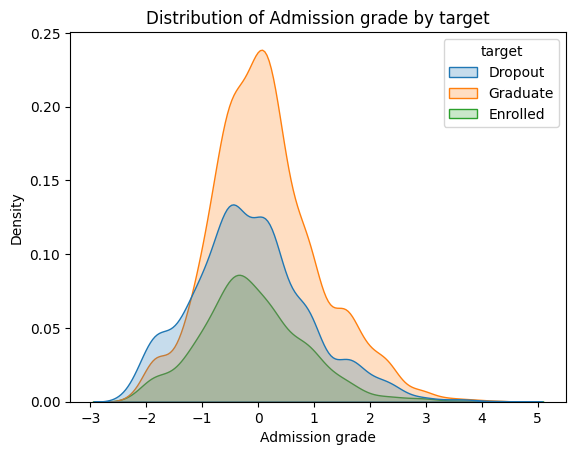

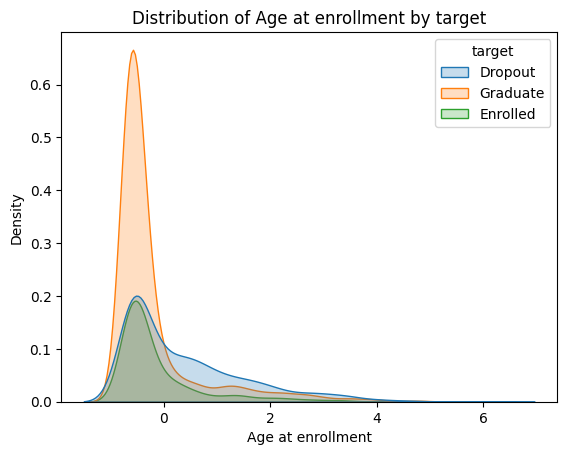

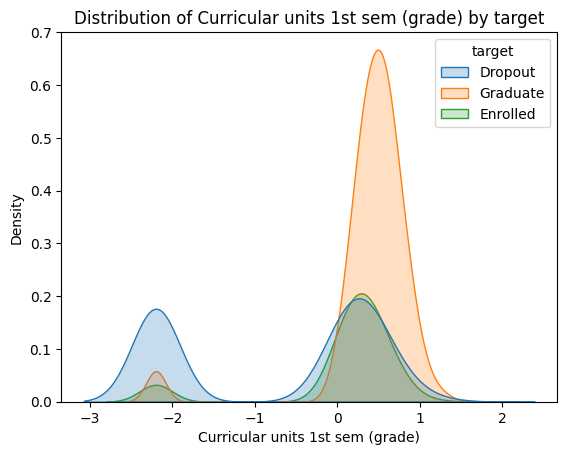

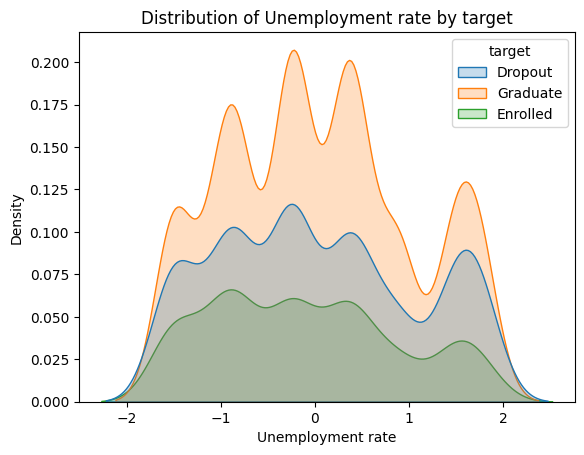

In [99]:
for col in ['Admission grade', 'Age at enrollment', 'Curricular units 1st sem (grade)', 'Unemployment rate']:
    sns.kdeplot(data=df, x=col, hue='target', fill=True)
    plt.title(f'Distribution of {col} by target')
    plt.show()


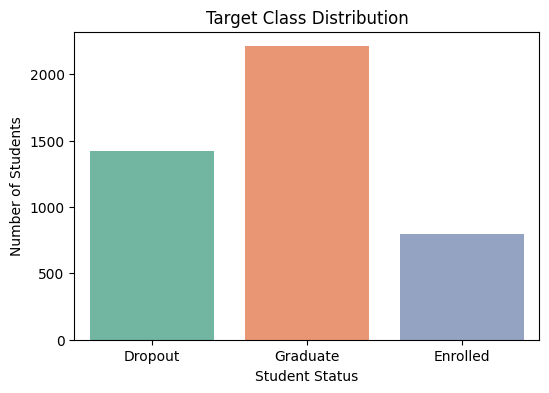

In [100]:
#Target class distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette= 'Set2')
plt.title("Target Class Distribution")
plt.ylabel("Number of Students")
plt.xlabel("Student Status")
plt.show()

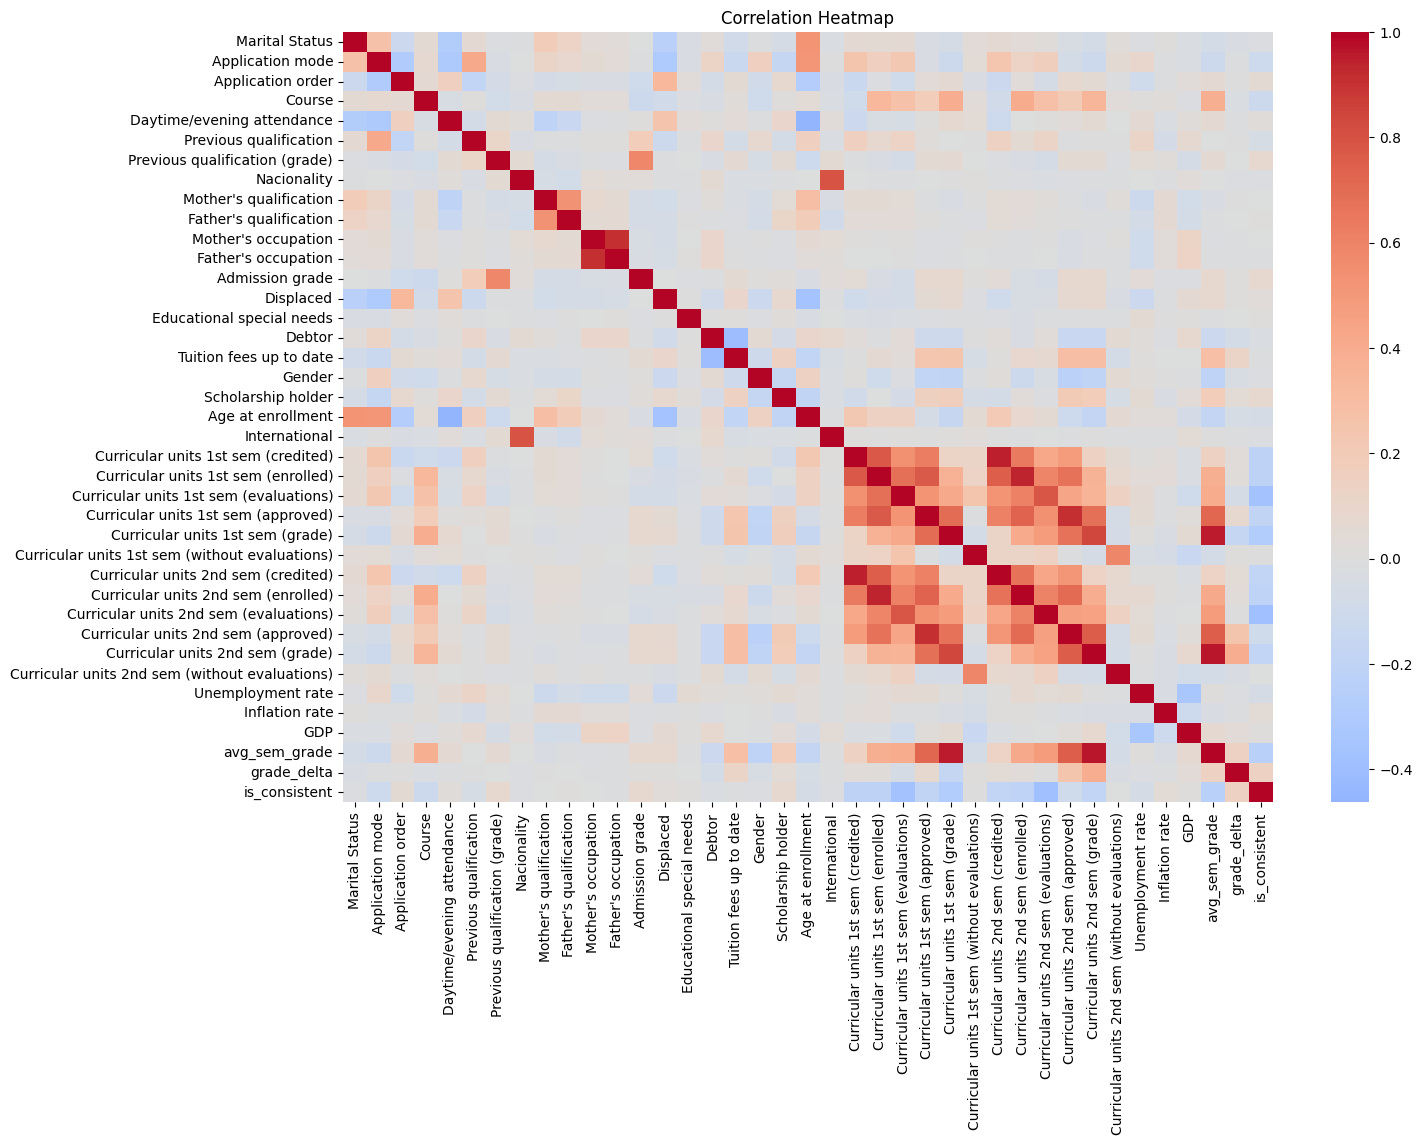

In [55]:
#Correlation heatmap of numerical features
plt.figure(figsize=(15, 10))
numeric_df = df.select_dtypes(include=['int64', 'float64'])
sns.heatmap(numeric_df.corr(), annot=False, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.show()

<ipython-input-58-e1f62963880c>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='target', y='Admission grade', palette='Set3')


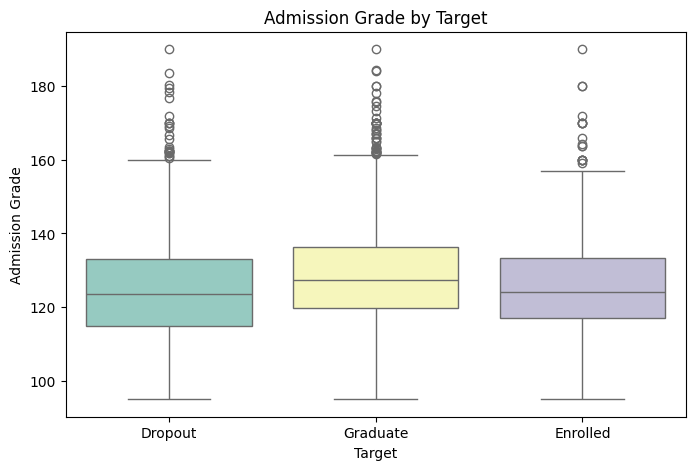

In [58]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='target', y='Admission grade', palette='Set3')
plt.title("Admission Grade by Target")
plt.xlabel("Target")
plt.ylabel("Admission Grade")
plt.show()


In [64]:
#Encoding target labels for easier processing
df['target_encoded'] = LabelEncoder().fit_transform(df['target'])
df['target_encoded'].head(5)

,target_encoded
0,0
1,2
2,0
3,2
4,2


In [65]:
df['target_encoded'].value_counts()

,count
target_encoded,
2,2209
0,1421
1,794


In [76]:
#Feature Engineering
df['avg_sem_grade'] = (df['Curricular units 1st sem (grade)'] + df['Curricular units 2nd sem (grade)']) / 2
df['grade_delta'] = df['Curricular units 2nd sem (grade)'] - df['Curricular units 1st sem (grade)']

In [77]:
#Pick numeric columns (ignoring target/object types)
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('target_encoded')

#Normalizing numeric features
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

In [82]:
#Splitting the dataset
X = df.drop(['target', 'target_encoded'], axis=1)
y = df['target_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [84]:
#Training 3 different models
rf = RandomForestClassifier(random_state=42)
xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
cat = CatBoostClassifier(verbose=0, random_state=42)

rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)
cat.fit(X_train, y_train)


 Random Forest Results:
Accuracy: 0.752542372881356
F1 Score: 0.7360914633031482
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.74      0.78       316
           1       0.47      0.29      0.36       151
           2       0.77      0.93      0.84       418

    accuracy                           0.75       885
   macro avg       0.68      0.65      0.66       885
weighted avg       0.73      0.75      0.74       885



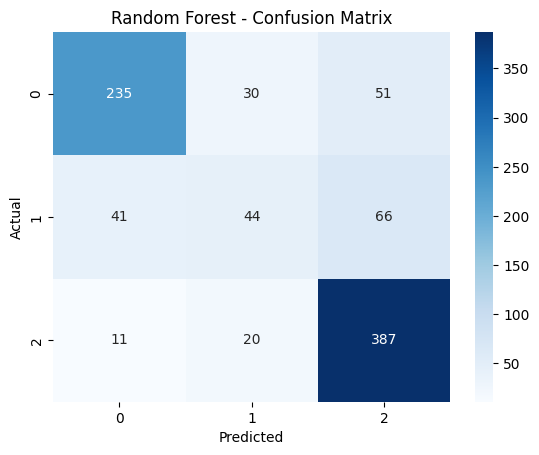


 XGBoost Results:
Accuracy: 0.7581920903954802
F1 Score: 0.7475422774018908
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.74      0.78       316
           1       0.48      0.36      0.41       151
           2       0.79      0.91      0.85       418

    accuracy                           0.76       885
   macro avg       0.70      0.67      0.68       885
weighted avg       0.75      0.76      0.75       885



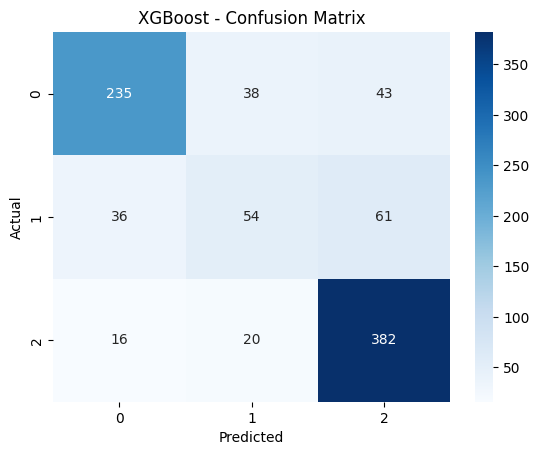


 CatBoost Results:
Accuracy: 0.7615819209039548
F1 Score: 0.7527860713601158
Classification Report:
               precision    recall  f1-score   support

           0       0.84      0.74      0.79       316
           1       0.48      0.38      0.42       151
           2       0.79      0.91      0.85       418

    accuracy                           0.76       885
   macro avg       0.70      0.68      0.69       885
weighted avg       0.75      0.76      0.75       885



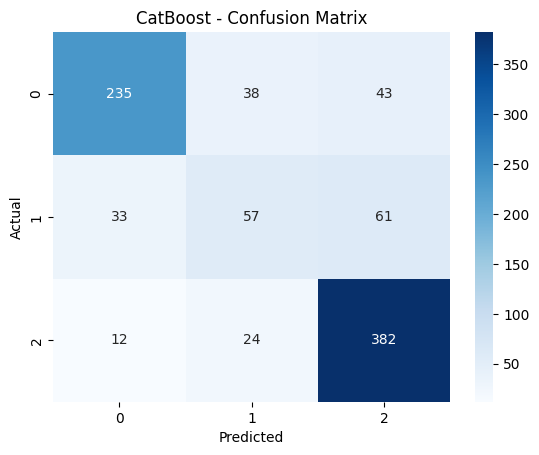

In [85]:
models = {'Random Forest': rf, 'XGBoost': xgb, 'CatBoost': cat}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"\n {name} Results:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
    print("Classification Report:\n", classification_report(y_test, y_pred))

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

In [87]:
#Cross-Validation Accuracy Scores
for name, model in models.items():
    cv_score = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f" {name} CV Accuracy: {np.mean(cv_score):.4f} ± {np.std(cv_score):.4f}")

 Random Forest CV Accuracy: 0.7712 ± 0.0041
 XGBoost CV Accuracy: 0.7728 ± 0.0168
 CatBoost CV Accuracy: 0.7746 ± 0.0092


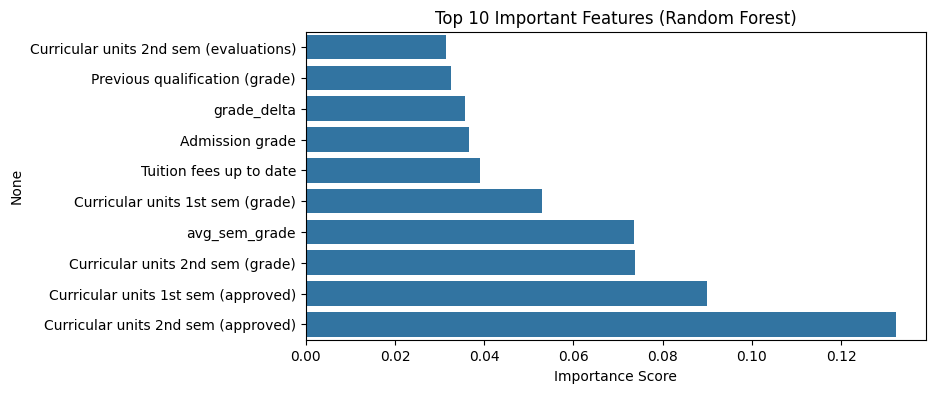

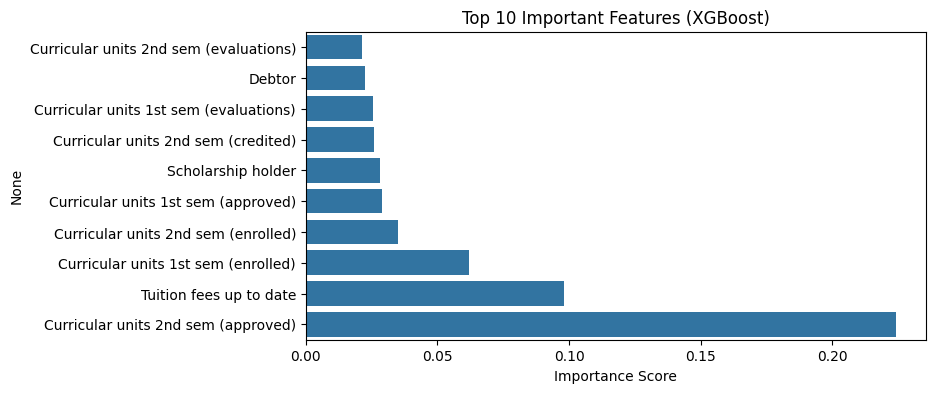

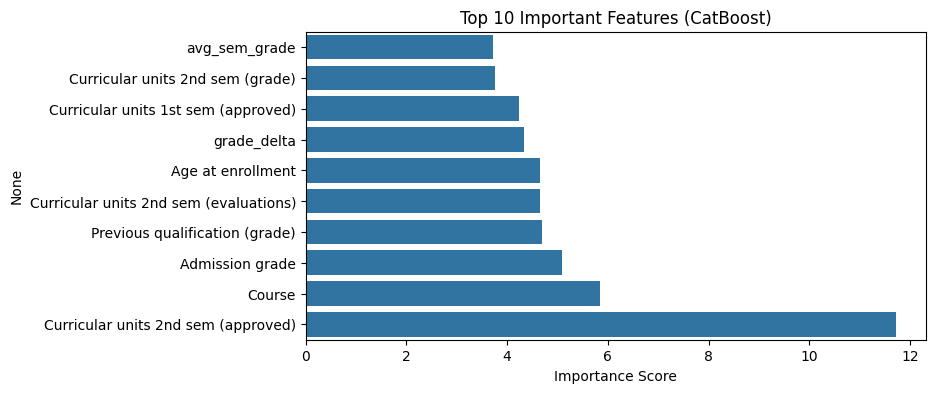

In [91]:
#Feature Importance plot
def plot_feature_importance(model, model_name):
    try:
        importances = model.feature_importances_
        indices = np.argsort(importances)[-10:]  # Top 10
        top_features = X.columns[indices]
        plt.figure(figsize=(8, 4))
        sns.barplot(x=importances[indices], y=top_features)
        plt.title(f"Top 10 Important Features ({model_name})")
        plt.xlabel("Importance Score")
        plt.show()
    except:
        print(f"{model_name} does not support feature importance extraction.")

for name, model in models.items():
    plot_feature_importance(model, name)

Ensemble Training & Evaluation Code: Voting Classifer


In [94]:
#Defining base models
rf_model = RandomForestClassifier(random_state=42)
xgb_model = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
cat_model = CatBoostClassifier(verbose=0, random_state=42)

#Defining Voting Ensemble
ensemble = VotingClassifier(
    estimators=[
        ('rf', rf_model),
        ('xgb', xgb_model),
        ('cat', cat_model)
    ],
    voting='soft'
)

#Fit model
ensemble.fit(X_train, y_train)


VotingClassifier(estimators=[('rf', RandomForestClassifier(random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric='mlogloss',
                                            feature_types=None, gamma=None,
                                            grow_policy=None,
                                            importan...
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=None, n_jobs=None,
                                            num_parallel_tree=None,
                                            random_state=42, ...)),
                             ('cat',
                              <catboost.core.CatBoostClassifier object at 0x7e549e4abe90>)],
                 voting='soft')

Ensemble Voting Classifier Results:
Accuracy: 0.7649717514124293
F1 Score: 0.7541327071958658
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.75      0.79       316
           1       0.51      0.37      0.43       151
           2       0.78      0.92      0.85       418

    accuracy                           0.76       885
   macro avg       0.71      0.68      0.69       885
weighted avg       0.75      0.76      0.75       885



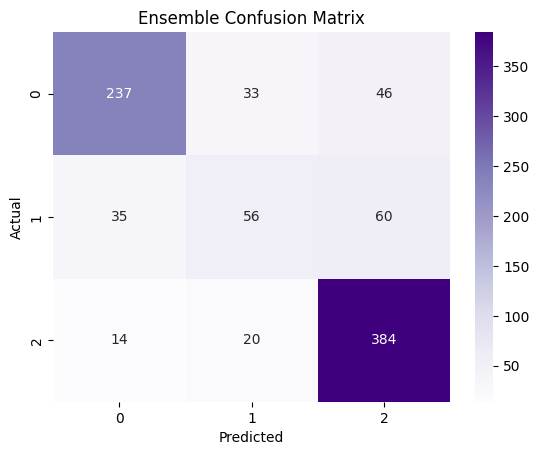

In [95]:
#Predict and evaluate
y_pred = ensemble.predict(X_test)

print("Ensemble Voting Classifier Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Classification Report:\n", classification_report(y_test, y_pred))

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Ensemble Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Ensemble Training & Evaluation Code: Stacking Classifer

In [97]:
#Defining base models
base_models = [
    ('gb', GradientBoostingClassifier(n_estimators=100, random_state=42)),
    ('svc', SVC(probability=True, kernel='rbf', C=1, gamma='scale', random_state=42)),
    ('et', ExtraTreesClassifier(n_estimators=100, random_state=42))
]

#Defining Meta-learner
meta_model = LogisticRegression(max_iter=1000)

#Building stacking classifier
stacked_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    n_jobs=-1
)

#Training model
stacked_clf.fit(X_train, y_train)

# # 6. Evaluate
# y_pred = stacked_clf.predict(X_test)

StackingClassifier(cv=5,
                   estimators=[('gb',
                                GradientBoostingClassifier(random_state=42)),
                               ('svc',
                                SVC(C=1, probability=True, random_state=42)),
                               ('et', ExtraTreesClassifier(random_state=42))],
                   final_estimator=LogisticRegression(max_iter=1000),
                   n_jobs=-1)

Stacking Classifier with Diverse Models:
Accuracy: 0.7672316384180791
F1 Score: 0.7583460576482173
Classification Report:
               precision    recall  f1-score   support

           0       0.85      0.76      0.80       316
           1       0.50      0.38      0.43       151
           2       0.78      0.91      0.84       418

    accuracy                           0.77       885
   macro avg       0.71      0.68      0.69       885
weighted avg       0.76      0.77      0.76       885



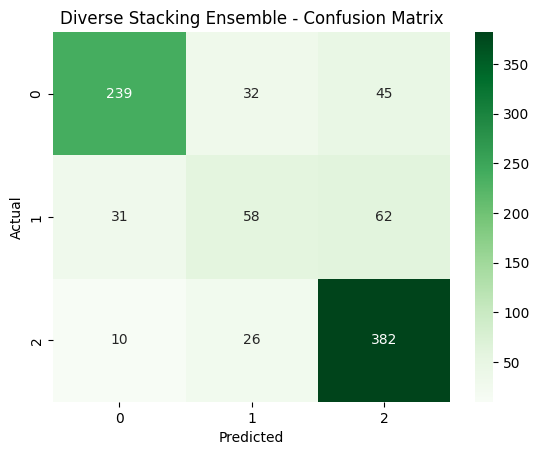

In [98]:
#Evaluatation
y_pred = stacked_clf.predict(X_test)

print("Stacking Classifier with Diverse Models:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average='weighted'))
print("Classification Report:\n", classification_report(y_test, y_pred))

#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Diverse Stacking Ensemble - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()